In [22]:
import cv2
import time
import random
from random import sample

from matplotlib import pyplot as plt
import math
import os
import numpy as np

import mediapipe as mp
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler


In [23]:
align_file_test = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S1/align/bbaf2s.align" 


def ParseAlign(align_file: str)-> list[bool, int, int]:
    """
    Provides Clip information for a single .align file
    Args:
        align_file: path to align file
    Returns:
        clip_alignments: [[sil,start_frame,end_frame],[sil,start_frame end_frame],[talking,start_frame,end_frame],[talking,start_frame,end_frame]]
    """

    with open(align_file, 'r') as file:
        clip_alignment = []
        start_talk=0
        end_talk=0
        for line in file:
            alignment = line.strip('\n').split(" ")
            start, end, word = alignment
            if word == "sil":
                start_frame = math.ceil(int(start)*0.001)
                end_frame = math.ceil(int(end)*0.001)
                clip_alignment.append(["sil", start_frame, end_frame])
                
            else:
                if start_talk == 0:
                    start_talk = math.ceil(int(start)*0.001)
                if math.ceil(int(end)*0.001) > end_talk:
                    end_talk = math.ceil(int(end)*0.001)
        midpoint = math.ceil(start_talk + (end_talk-start_talk)/2)
        clip_alignment.append(["talking", start_talk, midpoint])
        clip_alignment.append(["talking", midpoint, end_talk])
            

    return clip_alignment

ParseAlign(align_file=align_file_test)

[['sil', 0, 13], ['sil', 51, 75], ['talking', 13, 32], ['talking', 32, 51]]

In [24]:
FULL_GRID_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata"

def ParseDataset(path: str) -> list[bool, int, int, str]:
    """Given a formatted dataset, returns all clip infromation
    Args:
        path: path to dataset
    Returns:
        clip_alignments: [istalking: bool,start_frame:int,end_frame:int, videopath:str]"""

    dataset_abstracted = []
    for subject in os.listdir(path):
        try:
            align_folder = path + "/" + subject + "/align"
            video_folder = path + "/" + subject + "/" + subject
            for filename in os.listdir(align_folder):
                video_clip_name = filename.split(".")[0]+".mpg"
                video_path = video_folder + "/"+ video_clip_name
                alignments = ParseAlign(align_folder+"/"+filename)
                if os.path.isfile(video_path): #Try video path except skip
                    for alignment in alignments:
                        clip_values = [*alignment, video_path]
                        dataset_abstracted.append(clip_values)

        except Exception as e:
            print("Exception Error:", e)

    return dataset_abstracted

dataset_values = ParseDataset(FULL_GRID_DIR)
print(dataset_values[0])



['sil', 0, 14, '/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S4/S4/bbae9n.mpg']


In [25]:
MOUTH_LANDMARKS = [0, 267, 269, 270, 409, 306, 375, 321, 405, 314, 17, 84, 181, 91, 146, 61, 185, 40, 39,
                                37]

mpDraw = mp.solutions.drawing_utils
mpFaceMesh = mp.solutions.face_mesh
faceMesh = mpFaceMesh.FaceMesh(max_num_faces=2)
drawSpec = mpDraw.DrawingSpec(thickness=1, circle_radius=1)

def FindMouth(img, output_format):
    landmarks = []
    try:
        results = faceMesh.process(img)
        if results.multi_face_landmarks:
            for faceLms in results.multi_face_landmarks:
                # mpDraw.draw_landmarks(img, faceLms, mpFaceMesh.FACEMESH_CONTOURS, drawSpec, drawSpec)
                for id,lm in enumerate(faceLms.landmark):
                    image_height, image_width, image_channels = img.shape
                    x,y = int(lm.x*image_width), int(lm.y*image_height)
                    if output_format == "mouthrgb":
                        if id == 0:
                            return img[y-40:y+60,x-50:x+50,:]
                    if output_format == "liplandmarks":
                        if id in MOUTH_LANDMARKS:
                            landmarks.append((x,y))
            if landmarks:
                return landmarks
    except Exception as e:
        print("Failed to FindMouth:", e)
    return img
        

I0000 00:00:1744278823.278210 2607234 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1744278823.317550 3200738 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 4070/PCIe/SSE2


In [26]:
# frameformats -> mouthrgb, mouthgreyscale, liplandmarks, fullframe/face



class FrameGenerator():
    """Given an array of dataset values, returns labeled and formatted data/frames"""
    def __init__(self, dataset_values, training=False, frame_format="mouthrgb"):
        self.dataset_values = dataset_values
        self.training = training
        self.frame_format = frame_format
        
        match self.frame_format:
            case "mouthrgb":
                self.input_shape = (10, 100, 100, 3)
            case "liplandmarks":
                self.input_shape = (10, 2, 20)
                


    def __call__(self):
        if self.training:
            np.random.shuffle(self.dataset_values) #Use a different shuffle method?
            # print((self.dataset_values[0]))

        # print("Test dataset format" ,self.dataset_values)
        for isTalking, start_frame, end_frame, video_path in self.dataset_values:
            label = np.int16(0 if isTalking == "sil" else 1) 
            formatted_frames = []

            cap = cv2.VideoCapture(video_path)
            count = 0
            while count < self.input_shape[0]:
                cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame+count)
                ret, frame = cap.read()
                if not ret:
                    print("failed to read: " + video_path + str(count))
                    # time.sleep(1)
                    formatted_frames.append(np.zeros((self.input_shape[1],self.input_shape[2], 3), dtype=np.float32))
                else:
                    frame = FindMouth(frame, self.frame_format)
                    if self.frame_format == "mouthrgb":
                        frame = frame / 255
                        
                        frame = tf.image.resize_with_pad(frame,self.input_shape[1],self.input_shape[2]) 
                        frame = tf.image.convert_image_dtype(frame, tf.float32)
                    if self.frame_format == "liplandmarks":
                        pass
                    formatted_frames.append(frame)
                count += 1

            cap.release()

            while len(formatted_frames) < 10:
                formatted_frames.append(np.zeros((self.input_shape[1], self.input_shape[2], 3), dtype=np.float32))

            formatted_frames = np.array(formatted_frames, dtype=np.float32)
            # print(formatted_frames)
            if self.frame_format == "mouthrgb":
                formatted_frames = np.array(formatted_frames)[...,[2,1,0]]
            yield formatted_frames, label

    




print(len(dataset_values))
train_dataset_values = sample(dataset_values, 16000)
val_dataset_values = sample(dataset_values, 4000)
print(len(train_dataset_values), len(val_dataset_values))                    

fg = FrameGenerator(dataset_values, True)

first_item, label = next(fg())

print(first_item.shape, label)
# print(label)        

120000
16000 4000
(10, 100, 100, 3) 1


W0000 00:00:1744278823.321576 3200733 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1744278823.333868 3200736 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [27]:
# train_ds = train_ds.batch(2)
# val_ds = val_ds.batch(2)

input_shape = (10, 100, 100, 3)

output_signature = (tf.TensorSpec(shape = input_shape, dtype = tf.float32, name="frames"),
                    tf.TensorSpec(shape = (), dtype = tf.int16, name="labels"))
train_ds = tf.data.Dataset.from_generator(FrameGenerator(train_dataset_values, True),
                                          output_signature = output_signature)
val_ds = tf.data.Dataset.from_generator(FrameGenerator(val_dataset_values, True),
                                          output_signature = output_signature)

print(train_ds)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)
print(train_ds)
val_ds = val_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)

<_FlatMapDataset element_spec=(TensorSpec(shape=(10, 100, 100, 3), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(10, 100, 100, 3), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>


In [28]:
train_ds = train_ds.batch(2)
val_ds = val_ds.batch(2)

# print("Frames shape:", frames.shape)  # Should be (10, 100, 100, 3)
# print("Labels:", labels)  # Should be a single int16 label
for i in range(10):
    print(train_ds.take(i))

<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 100, 100, 3), 

In [29]:

start = time.time()

model = models.Sequential([

    layers.Input(shape=input_shape),
    # Input Layer
    # (2+1)D Conv Block 1
    layers.Conv3D(32, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(32, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(1, 2, 2)),

    # (2+1)D Conv Block 2
    layers.Conv3D(64, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(64, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    # (2+1)D Conv Block 3
    layers.Conv3D(128, kernel_size=(1, 3, 3), padding='same', activation='relu'),
    layers.Conv3D(128, kernel_size=(3, 1, 1), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling3D(pool_size=(2, 2, 2)),

    # Global Feature Aggregation
    layers.GlobalAveragePooling3D(),
    layers.Dropout(0.5),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output Layer (Binary Classification)
    layers.Dense(1, activation='sigmoid')  # Change from softmax to sigmoid
])



# Compile Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),  # Change loss function
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Model Summary
history = model.fit(train_ds, 
          epochs = 50,
          validation_data = val_ds,
          callbacks = tf.keras.callbacks.EarlyStopping(patience = 5, monitor = 'val_loss'))

Epoch 1/50
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S13/S13/bwizzn.mpg9
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S34/S34/lrwv1p.mpg5
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S34/S34/lrwv1p.mpg6
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S34/S34/lrwv1p.mpg7
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S34/S34/lrwv1p.mpg8
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S34/S34/lrwv1p.mpg9


2025-04-10 10:53:58.351343: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:53: Filling up shuffle buffer (this may take a while): 79 of 1000


failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg0
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg1
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg2
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg3
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg4
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg5
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg6
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg7
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg8
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S8/S8/sgbv2s.mpg9
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S29/S29/pwwh8p.mpg9


2025-04-10 10:54:08.353609: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:53: Filling up shuffle buffer (this may take a while): 159 of 1000


failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S11/S11/pgadzp.mpg3
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S11/S11/pgadzp.mpg4
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S11/S11/pgadzp.mpg5
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S11/S11/pgadzp.mpg6
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S11/S11/pgadzp.mpg7
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S11/S11/pgadzp.mpg8
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S11/S11/pgadzp.mpg9
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S26/S26/lgij1p.mpg9
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S29/S29/bric8p.mpg1
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S29/S29/bric8p.mpg2
failed to read: /media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S29/S29/bric8p.mpg3

...

8000/8000 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - accuracy: 0.9796 - loss: 0.0660 - precision_2: 0.9863 - recall_2: 0.9727 - val_accuracy: 0.9630 - val_loss: 0.1198 - val_precision_2: 0.9806 - val_recall_2: 0.9441
Epoch 18/50
  22/8000 ━━━━━━━━━━━━━━━━━━━━ 1:00 8ms/step - accuracy: 0.9388 - loss: 0.1250 - precision_2: 1.0000 - recall_2: 0.8788

2025-04-10 12:07:48.870243: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]


7998/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9811 - loss: 0.0606 - precision_2: 0.9884 - recall_2: 0.9737

2025-04-10 12:08:53.029819: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12327105551694015669
2025-04-10 12:08:53.029841: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 181315229100420221


8000/8000 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - accuracy: 0.9811 - loss: 0.0606 - precision_2: 0.9884 - recall_2: 0.9737 - val_accuracy: 0.9655 - val_loss: 0.1282 - val_precision_2: 0.9768 - val_recall_2: 0.9532


In [30]:
end = time.time()

print(end-start)
model.save_weights('./finaltest.weights.h5')

4514.6679039001465


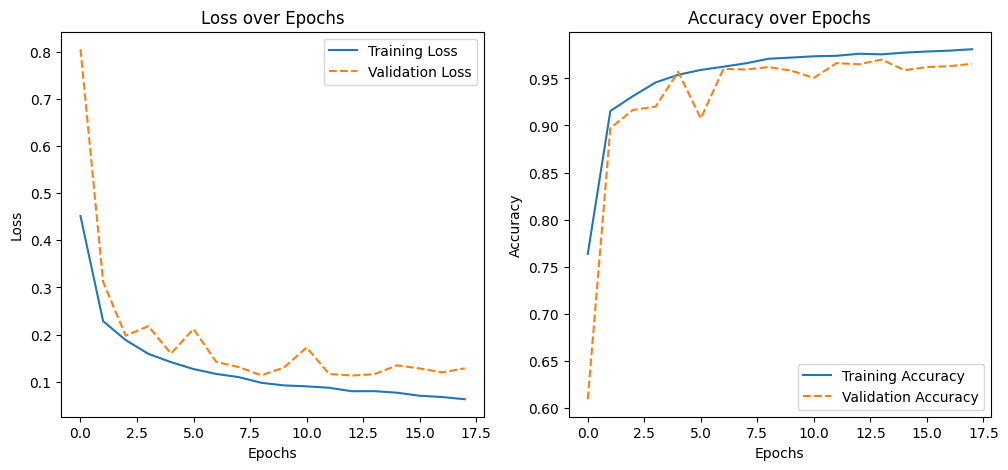

In [31]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')

    plt.show()

# Call the function
plot_history(history)

In [32]:
print(type(history.history['accuracy']))
print(history.history['precision'])


# for i in range(1, 10):
#     next_item, label = next(fg())
#     prediction = model.predict(next_item)
#     print("Prediction:", prediction[0][0], "Label", label)

<class 'list'>


KeyError: 'precision'

In [13]:
# input_shape=(10, 100, 100, 3)
# input_data="Mouth_RGB"
# def ReadFrames(full_path: str, start, end, isTalking):
#     video = cv2.VideoCapture(full_path)
#     frames = []
#     count = 0
#     while count < input_shape[0] and count <= end:
#         video.set(cv2.CAP_PROP_POS_FRAMES, start+count)
#         ret, frame = video.read()
#         if not ret:
#             break
#             # continue
        

#     frames.append(frame)

    
#     res, frame = video.read()

#     if not res:
#         print("failed to read")
    
   
    # video.release()
# Given a file, start and end frame, produce a len10 array of frames